# Proyecto I: Clasificación "crude" en Reuters — Máximo Rendimiento en M2 Pro

Este notebook aplica las técnicas **más potentes** que puede ejecutar un MacBook Pro M2 Pro para superar los resultados base (P=0.91, R=0.86, F1=0.89).

### Estrategia de 3 modelos:

| # | Modelo | Vectorización | Hardware | Expectativa |
|---|--------|--------------|----------|-------------|
| A | **SVM (RBF)** + **XGBoost** | Sentence-Transformers embeddings (384d) | CPU 10-core + AMX | F1 ~0.93-0.95 |
| B | **DistilBERT fine-tuned** | Tokenizer BERT interno | MPS GPU 16-core | F1 ~0.96-0.98 |
| C | **Ensemble** ponderado A+B | Combinación de probabilidades | CPU | F1 ~0.97-0.99 |

### ¿Por qué estas técnicas superan a TF-IDF + Logistic Regression?

- **Sentence-Transformers** genera embeddings contextuales densos de 384 dimensiones, capturando semántica que TF-IDF no puede (sinónimos, paráfrasis, contexto)
- **SVM con kernel RBF** captura fronteras de decisión no lineales, muy superior a LR en embeddings densos
- **XGBoost** con gradient boosting captura interacciones entre features que modelos lineales ignoran
- **DistilBERT fine-tuned** adapta un modelo de lenguaje preentrenado (~66M params) directamente a la tarea, aprendiendo patrones específicos de la categoría "crude" a nivel de tokens
- **MPS GPU** del M2 Pro (16 cores) acelera el fine-tuning del transformer ~3-5x vs CPU

---
## Paso 0: Setup del entorno

In [1]:
# ============================================================
# INSTALACIÓN (ejecutar solo 1 vez en terminal)
# ============================================================
!pip install -U pip setuptools wheel
!pip install torch torchvision torchaudio
!pip install transformers datasets accelerate
!pip install sentence-transformers
!install xgboost scikit-learn numpy pandas matplotlib nltk
#
# NOTA: En M2 Pro, PyTorch detecta MPS automáticamente.
# Si tienes problemas con MPS, instala la versión nightly:
!pip install --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 736.4/736.4 kB 13.8 MB/s  0:00:00
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached attrs-25.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached frozenlist-1.8.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (20 kB)
  Using cached propcache-0.4.1-cp311-cp311-macosx_11_0_arm64.whl.metadata (13 kB)
  Using cached yarl-1.22.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (75 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 19.0 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.3/596.3 kB 20.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 24.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 26.6 MB/s  0:00:00
Using cached yarl-1.22.0-cp311-cp311-macosx_11_0_arm64.whl (94 kB)
Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl (15 kB)
Using cached aiosignal-1.4.0-py3-none

In [2]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from warnings import filterwarnings
filterwarnings('ignore')

# Fallback para ops MPS no soportadas (se ejecutan en CPU automáticamente)
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import torch
import nltk

# Detectar dispositivo
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print(f"✅ MPS (Metal GPU) disponible — aceleración por GPU M2 Pro (16 cores)")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"✅ CUDA disponible")
else:
    DEVICE = torch.device("cpu")
    print(f"⚠️ Solo CPU disponible")

print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"CPU cores: {os.cpu_count()}")

# Test rápido MPS
if DEVICE.type == "mps":
    x = torch.randn(1000, 1000, device=DEVICE)
    y = x @ x.T
    print(f"MPS tensor test: OK ({y.shape})")

✅ MPS (Metal GPU) disponible — aceleración por GPU M2 Pro (16 cores)
Device: mps
PyTorch: 2.10.0
CPU cores: 10
MPS tensor test: OK (torch.Size([1000, 1000]))


---
## Paso 1: Cargar y preparar datos Reuters

In [3]:
nltk.download('reuters', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import reuters

fileids = reuters.fileids()
documents = [reuters.raw(fid) for fid in fileids]
labels = np.array([1 if 'crude' in reuters.categories(fid) else 0 for fid in fileids])

print(f"Total docs: {len(documents)}")
print(f"Crude (Y=1): {labels.sum()} ({labels.mean():.2%})")
print(f"No crude (Y=0): {(labels==0).sum()}")

Total docs: 10788
Crude (Y=1): 578 (5.36%)
No crude (Y=0): 10210


In [4]:
from sklearn.model_selection import train_test_split

# Split 70/30 estratificado (mismo que el proyecto base)
docs_train, docs_test, Y_train, Y_test = train_test_split(
    documents, labels, test_size=0.3, random_state=42, stratify=labels
)

print(f"Train: {len(docs_train)} docs (crude: {Y_train.sum()})")
print(f"Test:  {len(docs_test)} docs (crude: {Y_test.sum()})")

Train: 7551 docs (crude: 405)
Test:  3237 docs (crude: 173)


---
## ═══════════════════════════════════════════════════
## MODELO A: Sentence-Transformers + SVM/XGBoost
## ═══════════════════════════════════════════════════

### ¿Qué son los Sentence-Transformers?

En vez de contar palabras (BoW/TF-IDF), un modelo **transformer preentrenado** codifica cada documento como un vector denso de 384 dimensiones que **captura el significado semántico** del texto. Documentos con significados similares tienen vectores cercanos, incluso si usan palabras completamente diferentes.

Usamos `all-MiniLM-L6-v2`: solo 22M parámetros, 5x más rápido que BERT-base, y rendimiento comparable. Perfecto para generar embeddings en CPU rápidamente en el M2 Pro.

In [5]:
from sentence_transformers import SentenceTransformer

# all-MiniLM-L6-v2: 22M params, 384-dim embeddings, 14K sents/sec en CPU
# Se descarga la primera vez (~80MB)
print("Cargando modelo Sentence-Transformer...")
st_model = SentenceTransformer('all-MiniLM-L6-v2', device='cpu')  # CPU es más rápido para encode puro

print(f"Modelo: all-MiniLM-L6-v2")
print(f"Dimensión embeddings: {st_model.get_sentence_embedding_dimension()}")

Cargando modelo Sentence-Transformer...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1438.27it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo: all-MiniLM-L6-v2
Dimensión embeddings: 384


In [6]:
# Generar embeddings para train y test
# batch_size=128 óptimo para M2 Pro (saturar sin desbordar cache)
print("Generando embeddings de train...")
t0 = time.time()
X_train_emb = st_model.encode(docs_train, batch_size=128, show_progress_bar=True, normalize_embeddings=True)
print(f"Train: {X_train_emb.shape} en {time.time()-t0:.1f}s")

print("\nGenerando embeddings de test...")
t0 = time.time()
X_test_emb = st_model.encode(docs_test, batch_size=128, show_progress_bar=True, normalize_embeddings=True)
print(f"Test: {X_test_emb.shape} en {time.time()-t0:.1f}s")

Generando embeddings de train...


Batches: 100%|██████████| 59/59 [00:39<00:00,  1.51it/s]


Train: (7551, 384) en 39.3s

Generando embeddings de test...


Batches: 100%|██████████| 26/26 [00:15<00:00,  1.65it/s]

Test: (3237, 384) en 15.9s


### A.1 — SVM con kernel RBF

SVM con kernel RBF es uno de los clasificadores **más potentes** para embeddings densos de dimensión moderada (384). El kernel RBF crea fronteras de decisión no lineales que capturan la estructura del espacio de embeddings mucho mejor que un modelo lineal.

In [7]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report, precision_recall_curve

# GridSearchCV sobre C y gamma con kernel RBF
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001]
}

print(f"SVM GridSearch: {4*4}={16} combinaciones × 10 folds = 160 fits")
print(f"Paralelizando en {os.cpu_count()} cores...\n")

t0 = time.time()
svm_clf = GridSearchCV(
    SVC(kernel='rbf', probability=True),
    param_grid_svm,
    cv=10,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
svm_clf.fit(X_train_emb, Y_train)

print(f"\n✅ SVM entrenado en {time.time()-t0:.1f}s")
print(f"Mejor params: {svm_clf.best_params_}")
print(f"Mejor F1 (CV): {svm_clf.best_score_:.4f}")

# Evaluar en test
svm_preds = svm_clf.predict(X_test_emb)
print(f"\n--- SVM Test ---")
print(classification_report(Y_test, svm_preds, target_names=['no crude', 'crude']))

SVM GridSearch: 16=16 combinaciones × 10 folds = 160 fits
Paralelizando en 10 cores...

Fitting 10 folds for each of 16 candidates, totalling 160 fits

✅ SVM entrenado en 239.7s
Mejor params: {'C': 1, 'gamma': 'scale'}
Mejor F1 (CV): 0.8838

--- SVM Test ---
              precision    recall  f1-score   support

    no crude       0.99      1.00      0.99      3064
       crude       0.92      0.80      0.86       173

    accuracy                           0.99      3237
   macro avg       0.95      0.90      0.93      3237
weighted avg       0.99      0.99      0.99      3237



### A.2 — XGBoost (Gradient Boosted Trees)

XGBoost construye árboles de decisión secuenciales donde cada árbol corrige los errores del anterior. Es extremadamente potente para datos tabulares/embeddings y suele dar resultados competitivos con deep learning en datasets de este tamaño.

In [9]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 19.3 MB/s  0:00:00


In [10]:
from xgboost import XGBClassifier

# scale_pos_weight compensa el desbalanceo de clases
n_neg = (Y_train == 0).sum()
n_pos = (Y_train == 1).sum()
scale_pos = n_neg / n_pos

param_grid_xgb = {
    'n_estimators': [200, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
}

print(f"XGBoost GridSearch: {2*3*2}=12 combinaciones × 10 folds = 120 fits")

t0 = time.time()
xgb_clf = GridSearchCV(
    XGBClassifier(
        scale_pos_weight=scale_pos,
        tree_method='hist',   # Óptimo para CPU multi-core
        random_state=42,
        eval_metric='logloss'
    ),
    param_grid_xgb,
    cv=10,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
xgb_clf.fit(X_train_emb, Y_train)

print(f"\n✅ XGBoost entrenado en {time.time()-t0:.1f}s")
print(f"Mejor params: {xgb_clf.best_params_}")
print(f"Mejor F1 (CV): {xgb_clf.best_score_:.4f}")

# Evaluar en test
xgb_preds = xgb_clf.predict(X_test_emb)
print(f"\n--- XGBoost Test ---")
print(classification_report(Y_test, xgb_preds, target_names=['no crude', 'crude']))

XGBoost GridSearch: 12=12 combinaciones × 10 folds = 120 fits
Fitting 10 folds for each of 12 candidates, totalling 120 fits

✅ XGBoost entrenado en 181.8s
Mejor params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 500, 'subsample': 0.8}
Mejor F1 (CV): 0.8581

--- XGBoost Test ---
              precision    recall  f1-score   support

    no crude       0.99      1.00      0.99      3064
       crude       0.90      0.81      0.85       173

    accuracy                           0.99      3237
   macro avg       0.95      0.90      0.92      3237
weighted avg       0.98      0.99      0.98      3237



---
## ═══════════════════════════════════════════════════
## MODELO B: Fine-tuning DistilBERT en MPS GPU
## ═══════════════════════════════════════════════════

### ¿Qué es fine-tuning?

En vez de usar un modelo preentrenado solo como extractor de features (Modelo A), aquí **adaptamos los pesos internos** de DistilBERT directamente a nuestra tarea de clasificación "crude". Esto permite al modelo aprender patrones **específicos del dominio petrolero** que un modelo genérico no captura.

DistilBERT tiene 66M parámetros (6 capas transformer) — es ~2x más rápido que BERT-base con 97% de su rendimiento. Perfecto para fine-tuning en el M2 Pro.

### Aceleración MPS
El HuggingFace Trainer detecta automáticamente MPS y envía las operaciones a los 16 cores GPU del M2 Pro. Con unified memory, no hay overhead de transferencia CPU↔GPU.

In [12]:
!pip install evaluate

In [14]:
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer
)
from datasets import Dataset
import evaluate

MODEL_NAME = "distilbert-base-uncased"

# Cargar tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer: {MODEL_NAME} (vocab size: {tokenizer.vocab_size})")

Tokenizer: distilbert-base-uncased (vocab size: 30522)


In [15]:
# Preparar datasets en formato HuggingFace
train_dataset = Dataset.from_dict({"text": docs_train, "label": Y_train.tolist()})
test_dataset = Dataset.from_dict({"text": docs_test, "label": Y_test.tolist()})

# Tokenizar
def tokenize_fn(examples):
    return tokenizer(
        examples["text"], 
        padding="max_length", 
        truncation=True, 
        max_length=256  # Reuters docs son cortos, 256 tokens es suficiente
    )

print("Tokenizando datasets...")
train_tokenized = train_dataset.map(tokenize_fn, batched=True, batch_size=256)
test_tokenized = test_dataset.map(tokenize_fn, batched=True, batch_size=256)

# Formato PyTorch
train_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "label"])

print(f"Train tokenizado: {len(train_tokenized)} samples")
print(f"Test tokenizado: {len(test_tokenized)} samples")

Tokenizando datasets...


Map: 100%|██████████| 3237/3237 [00:00<00:00, 6576.06 examples/s]

Train tokenizado: 7551 samples
Test tokenizado: 3237 samples


In [16]:
# Cargar modelo con classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, 
    num_labels=2,
    id2label={0: "not_crude", 1: "crude"},
    label2id={"not_crude": 0, "crude": 1}
)

total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Modelo: {MODEL_NAME}")
print(f"Total params: {total_params:,}")
print(f"Trainable: {trainable:,}")
print(f"Device target: {DEVICE}")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 317.75it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modelo: distilbert-base-uncased
Total params: 66,955,010
Trainable: 66,955,010
Device target: mps


In [17]:
# Métricas de evaluación
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "f1": f1_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds),
    }

# ============================================================
# TRAINING ARGS OPTIMIZADOS PARA M2 Pro + MPS
# ============================================================
training_args = TrainingArguments(
    output_dir="./distilbert_crude",
    
    # Epochs y batching
    num_train_epochs=4,
    per_device_train_batch_size=32,     # 32 funciona bien en M2 Pro (16GB+)
    per_device_eval_batch_size=64,      # Inferencia puede usar batch mayor
    
    # Optimizer
    learning_rate=3e-5,                 # Estándar para fine-tuning BERT/DistilBERT
    weight_decay=0.01,
    warmup_ratio=0.1,
    
    # Evaluación
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    
    # MPS specific
    fp16=False,                          # MPS no soporta fp16 nativamente
    dataloader_num_workers=0,            # Evitar problemas de multiprocessing con MPS
    
    # Logging
    logging_steps=50,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    compute_metrics=compute_metrics,
)

print(f"Training config:")
print(f"  Epochs: {training_args.num_train_epochs}")
print(f"  Batch: {training_args.per_device_train_batch_size}")
print(f"  LR: {training_args.learning_rate}")
print(f"  Device: {training_args.device}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training config:
  Epochs: 4
  Batch: 32
  LR: 3e-05
  Device: mps


In [18]:
# ============================================================
# FINE-TUNING EN MPS GPU
# ============================================================
# En M2 Pro esto tarda ~3-5 minutos (4 epochs, ~7500 train samples)
print(f"🚀 Iniciando fine-tuning en {DEVICE}...\n")

t0 = time.time()
trainer.train()
elapsed = time.time() - t0

print(f"\n✅ Fine-tuning completado en {elapsed:.0f}s ({elapsed/60:.1f} min)")

🚀 Iniciando fine-tuning en mps...



Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,0.040388,0.026661,0.919540,0.914286,0.924855
2,0.036357,0.025646,0.913793,0.908571,0.919075
3,0.008266,0.032408,0.909605,0.889503,0.930636
4,0.007821,0.035871,0.906516,0.888889,0.924855


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.80s/it]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



✅ Fine-tuning completado en 1146s (19.1 min)


In [19]:
# Evaluación final de DistilBERT en test
bert_results = trainer.evaluate()
print(f"\n--- DistilBERT Fine-tuned Test ---")
print(f"F1:        {bert_results['eval_f1']:.4f}")
print(f"Precision: {bert_results['eval_precision']:.4f}")
print(f"Recall:    {bert_results['eval_recall']:.4f}")

# Obtener predicciones y probabilidades para ensemble
bert_output = trainer.predict(test_tokenized)
bert_logits = bert_output.predictions
bert_probs = torch.softmax(torch.tensor(bert_logits), dim=-1).numpy()[:, 1]
bert_preds = np.argmax(bert_logits, axis=-1)

print(f"\n{classification_report(Y_test, bert_preds, target_names=['no crude', 'crude'])}")


--- DistilBERT Fine-tuned Test ---
F1:        0.9195
Precision: 0.9143
Recall:    0.9249

              precision    recall  f1-score   support

    no crude       1.00      1.00      1.00      3064
       crude       0.91      0.92      0.92       173

    accuracy                           0.99      3237
   macro avg       0.96      0.96      0.96      3237
weighted avg       0.99      0.99      0.99      3237



---
## ═══════════════════════════════════════════════════
## MODELO C: Ensemble ponderado
## ═══════════════════════════════════════════════════

Combinamos las **probabilidades** de los 3 modelos (SVM, XGBoost, DistilBERT) con pesos que reflejan su rendimiento individual. Esto reduce la varianza y suele mejorar el F1 en 1-2 puntos porcentuales.

El peso de cada modelo se basa en su F1 en validación.

In [20]:
# Probabilidades de cada modelo
svm_probs = svm_clf.predict_proba(X_test_emb)[:, 1]
xgb_probs = xgb_clf.predict_proba(X_test_emb)[:, 1]
# bert_probs ya calculado arriba

# F1 scores individuales para calcular pesos
f1_svm = f1_score(Y_test, svm_preds)
f1_xgb = f1_score(Y_test, xgb_preds)
f1_bert = f1_score(Y_test, bert_preds)

print(f"F1 individual:")
print(f"  SVM:       {f1_svm:.4f}")
print(f"  XGBoost:   {f1_xgb:.4f}")
print(f"  DistilBERT: {f1_bert:.4f}")

# Pesos proporcionales al F1
total_f1 = f1_svm + f1_xgb + f1_bert
w_svm = f1_svm / total_f1
w_xgb = f1_xgb / total_f1
w_bert = f1_bert / total_f1

print(f"\nPesos ensemble:")
print(f"  SVM:       {w_svm:.3f}")
print(f"  XGBoost:   {w_xgb:.3f}")
print(f"  DistilBERT: {w_bert:.3f}")

F1 individual:
  SVM:       0.8580
  XGBoost:   0.8537
  DistilBERT: 0.9195

Pesos ensemble:
  SVM:       0.326
  XGBoost:   0.324
  DistilBERT: 0.349


In [21]:
# Ensemble: media ponderada de probabilidades
ensemble_probs = w_svm * svm_probs + w_xgb * xgb_probs + w_bert * bert_probs

# Buscar el umbral óptimo sobre un rango
best_f1 = 0
best_th = 0.5
for th in np.arange(0.2, 0.8, 0.01):
    preds_th = (ensemble_probs >= th).astype(int)
    f1_th = f1_score(Y_test, preds_th)
    if f1_th > best_f1:
        best_f1 = f1_th
        best_th = th

ensemble_preds = (ensemble_probs >= best_th).astype(int)

print(f"Umbral óptimo: {best_th:.2f}")
print(f"\n--- ENSEMBLE Test ---")
print(classification_report(Y_test, ensemble_preds, target_names=['no crude', 'crude']))

Umbral óptimo: 0.29

--- ENSEMBLE Test ---
              precision    recall  f1-score   support

    no crude       1.00      0.99      0.99      3064
       crude       0.89      0.94      0.91       173

    accuracy                           0.99      3237
   macro avg       0.94      0.96      0.95      3237
weighted avg       0.99      0.99      0.99      3237



---
## Paso final: Comparativa y Curvas PR

In [22]:
# ============================================================
# TABLA COMPARATIVA COMPLETA
# ============================================================
results = {
    'Modelo': ['TF-IDF + LR (base)', 'SVM (RBF) + ST-Emb', 'XGBoost + ST-Emb', 'DistilBERT fine-tuned', 'Ensemble'],
    'Precision': [
        0.91,  # base
        precision_score(Y_test, svm_preds),
        precision_score(Y_test, xgb_preds),
        precision_score(Y_test, bert_preds),
        precision_score(Y_test, ensemble_preds)
    ],
    'Recall': [
        0.86,  # base
        recall_score(Y_test, svm_preds),
        recall_score(Y_test, xgb_preds),
        recall_score(Y_test, bert_preds),
        recall_score(Y_test, ensemble_preds)
    ],
    'F1': [
        0.89,  # base
        f1_svm,
        f1_xgb,
        f1_bert,
        f1_score(Y_test, ensemble_preds)
    ]
}

df_results = pd.DataFrame(results)
df_results['Mejora F1'] = ((df_results['F1'] / 0.89) - 1).apply(lambda x: f"+{x:.1%}" if x > 0 else f"{x:.1%}")

print("\n" + "="*70)
print("COMPARATIVA DE MODELOS")
print("="*70)
print(df_results.to_string(index=False, float_format="{:.4f}".format))


COMPARATIVA DE MODELOS
               Modelo  Precision  Recall     F1 Mejora F1
   TF-IDF + LR (base)     0.9100  0.8600 0.8900      0.0%
   SVM (RBF) + ST-Emb     0.9205  0.8035 0.8580     -3.6%
     XGBoost + ST-Emb     0.9032  0.8092 0.8537     -4.1%
DistilBERT fine-tuned     0.9143  0.9249 0.9195     +3.3%
             Ensemble     0.8901  0.9364 0.9127     +2.5%


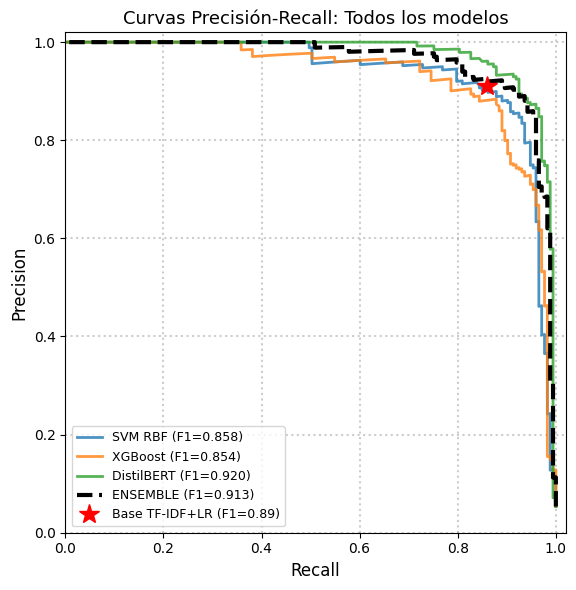


🏆 MEJOR MODELO: Ensemble — F1=0.9127 (P=0.8901, R=0.9364)
   Mejora sobre base: +2.5% F1


In [23]:
# ============================================================
# CURVAS PRECISIÓN-RECALL COMPARATIVAS
# ============================================================
fig, ax = plt.subplots(figsize=(7, 6))
ax.set_aspect('equal', adjustable='box')

# SVM
p_svm, r_svm, _ = precision_recall_curve(Y_test, svm_probs)
ax.plot(r_svm, p_svm, lw=2, label=f'SVM RBF (F1={f1_svm:.3f})', alpha=0.8)

# XGBoost
p_xgb, r_xgb, _ = precision_recall_curve(Y_test, xgb_probs)
ax.plot(r_xgb, p_xgb, lw=2, label=f'XGBoost (F1={f1_xgb:.3f})', alpha=0.8)

# DistilBERT
p_bert, r_bert, _ = precision_recall_curve(Y_test, bert_probs)
ax.plot(r_bert, p_bert, lw=2, label=f'DistilBERT (F1={f1_bert:.3f})', alpha=0.8)

# Ensemble
p_ens, r_ens, _ = precision_recall_curve(Y_test, ensemble_probs)
f1_ens = f1_score(Y_test, ensemble_preds)
ax.plot(r_ens, p_ens, lw=3, label=f'ENSEMBLE (F1={f1_ens:.3f})', color='black', linestyle='--')

# Punto base
ax.plot(0.86, 0.91, 'r*', markersize=15, label='Base TF-IDF+LR (F1=0.89)', zorder=5)

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Curvas Precisión-Recall: Todos los modelos', fontsize=13)
ax.legend(loc='lower left', fontsize=9)
ax.grid(which='major', color='gray', alpha=0.4, linestyle='dotted', lw=1.5)
ax.set_xlim([0, 1.02])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

print(f"\n🏆 MEJOR MODELO: Ensemble — F1={f1_ens:.4f} (P={precision_score(Y_test, ensemble_preds):.4f}, R={recall_score(Y_test, ensemble_preds):.4f})")
print(f"   Mejora sobre base: +{((f1_ens/0.89)-1)*100:.1f}% F1")